# Modeling Dataset EDA

This notebook performs exploratory data analysis for the final machine-learning modeling dataset used in the GRAD 504 project.

**Expected Python environment / kernel:** `Python (.venv) - Netflix_Viewership_Group_9`

The analysis is designed to run from the repository's existing `.venv` and uses repository-relative paths only.


## 1. Imports and Configuration


In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed" / "netflix_imdb_modeling.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "processed"
MODELING_PATH = DATA_DIR / "netflix_imdb_modeling.csv"
ENRICHED_PATH = DATA_DIR / "netflix_imdb_master_matched_enriched.csv"
MANIFEST_PATH = DATA_DIR / "netflix_imdb_modeling_feature_manifest.csv"

modeling_df = pd.read_csv(MODELING_PATH)
enriched_df = pd.read_csv(ENRICHED_PATH) if ENRICHED_PATH.exists() else None
manifest_df = pd.read_csv(MANIFEST_PATH) if MANIFEST_PATH.exists() else None

TARGET_COLUMN = "target_is_viewership_increase"
TARGET_COLUMNS_KNOWN = [
    "target_next_season_views",
    "target_view_change_absolute",
    "target_view_change_percent",
    "target_is_viewership_increase",
    "target_next_season_hours",
    "target_hours_change_absolute",
    "target_hours_change_percent",
    "target_is_hours_increase",
]
IDENTIFIER_PRIORITY = [
    "netflix_row_id",
    "series_group_key",
    "netflix_series_title",
    "season_order",
    "netflix_title_raw",
]

if manifest_df is not None:
    manifest_present = manifest_df[manifest_df["column_name"].isin(modeling_df.columns)].copy()
    identifier_cols = manifest_present.loc[manifest_present["role"] == "identifier", "column_name"].tolist()
    predictor_cols = manifest_present.loc[manifest_present["role"] == "predictor", "column_name"].tolist()
    target_cols = manifest_present.loc[manifest_present["role"] == "target", "column_name"].tolist()
    dropped_manifest_cols = manifest_df.loc[manifest_df["role"] == "dropped", "column_name"].tolist()
else:
    manifest_present = None
    target_cols = [col for col in TARGET_COLUMNS_KNOWN if col in modeling_df.columns]
    identifier_cols = [col for col in IDENTIFIER_PRIORITY if col in modeling_df.columns]
    predictor_cols = [col for col in modeling_df.columns if col not in set(identifier_cols + target_cols)]
    dropped_manifest_cols = []

predictor_cols = [col for col in predictor_cols if col in modeling_df.columns]
identifier_cols = [col for col in identifier_cols if col in modeling_df.columns]
target_cols = [col for col in target_cols if col in modeling_df.columns]

predictor_df = modeling_df[predictor_cols].copy()
numeric_predictors = predictor_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_predictors = [col for col in predictor_cols if col not in numeric_predictors]

duplicate_row_count = int(modeling_df.duplicated().sum())
duplicate_netflix_row_id_count = int(modeling_df["netflix_row_id"].duplicated().sum()) if "netflix_row_id" in modeling_df.columns else np.nan

def outcome_label(value):
    return "Increase" if value == 1 else "No Increase"

def draw_labeled_bar(ax, series, color="#4C78A8", horizontal=False, percent_denominator=None):
    if horizontal:
        ax.barh(series.index.astype(str), series.values, color=color)
        for idx, value in enumerate(series.values):
            ax.text(value, idx, f" {value:,.0f}", va="center")
    else:
        ax.bar(series.index.astype(str), series.values, color=color)
        ymax = max(series.values) if len(series.values) else 0
        offset = ymax * 0.02 if ymax else 0.1
        for idx, value in enumerate(series.values):
            label = f"{value:,.0f}"
            if percent_denominator:
                label += f"\n({value / percent_denominator:.1%})"
            ax.text(idx, value + offset, label, ha="center", va="bottom", fontsize=10)

def make_corr_matrix_plot(df, title):
    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.columns)
    ax.set_title(title)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return corr

def cramers_v_from_table(table: pd.DataFrame) -> float:
    chi2, _, _, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return np.nan
    return float(np.sqrt(phi2corr / denom))

display(Markdown(
    f"""        Repository root: `{ROOT}`

Modeling dataset: `{MODELING_PATH.relative_to(ROOT)}`

Enriched reference dataset loaded: `{ENRICHED_PATH.exists()}`

Feature manifest loaded: `{MANIFEST_PATH.exists()}`
"""
))


ModuleNotFoundError: No module named 'numpy'

## 2. Dataset Overview


In [ ]:
print(f"Modeling dataset shape: {modeling_df.shape}")
print(f"Rows: {len(modeling_df):,}")
print(f"Columns: {modeling_df.shape[1]:,}")


Modeling dataset shape: (3418, 95)
Rows: 3,418
Columns: 95


In [ ]:
display(pd.DataFrame({"column_name": modeling_df.columns}))


,column_name
0,netflix_row_id
1,series_group_key
2,imdb_parent_tconst
3,imdb_enrichment_entity_id
4,imdb_resolved_tconst
5,netflix_series_title
6,netflix_title_raw
7,imdb_primary_title
8,imdb_match_entity_type
9,netflix_season_number


In [ ]:
dtype_summary = pd.DataFrame({
    "column_name": modeling_df.columns,
    "dtype": modeling_df.dtypes.astype(str).values,
})
display(dtype_summary)

print(f"Numeric predictor count: {len(numeric_predictors)}")
print(f"Categorical predictor count: {len(categorical_predictors)}")
print(f"Duplicate row count: {duplicate_row_count:,}")
print(f"Duplicate netflix_row_id count: {duplicate_netflix_row_id_count:,}")


,column_name,dtype
0,netflix_row_id,int64
1,series_group_key,str
2,imdb_parent_tconst,str
3,imdb_enrichment_entity_id,str
4,imdb_resolved_tconst,str
5,netflix_series_title,str
6,netflix_title_raw,str
7,imdb_primary_title,str
8,imdb_match_entity_type,str
9,netflix_season_number,int64


Numeric predictor count: 73
Categorical predictor count: 4
Duplicate row count: 0
Duplicate netflix_row_id count: 0


In [ ]:
display(modeling_df.describe(include="all").transpose())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
netflix_row_id,"3,418.0000",NaN,NaN,NaN,"10,616.6071","7,475.2782",12.0000,"4,281.7500","9,292.5000","15,820.7500","28,425.0000"
series_group_key,3418,1390,tt0131179,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_parent_tconst,3418,1390,tt0131179,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_enrichment_entity_id,3418,1390,tt0131179,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_resolved_tconst,3418,1390,tt0131179,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
netflix_series_title,3418,1389,Detective Conan,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
netflix_title_raw,3418,3418,Star Trek: Season 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_primary_title,3418,1388,Detective Conan,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imdb_match_entity_type,3418,1,series_season,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
netflix_season_number,"3,418.0000",NaN,NaN,NaN,3.1972,3.4062,1.0000,1.0000,2.0000,4.0000,31.0000


In [ ]:
if manifest_df is not None:
    manifest_summary = pd.DataFrame({
        "group": ["identifier", "predictor", "target", "excluded feature"],
        "count": [
            int((manifest_df["role"] == "identifier").sum()),
            int((manifest_df["role"] == "predictor").sum()),
            int((manifest_df["role"] == "target").sum()),
            int((manifest_df["role"] == "dropped").sum()),
        ],
    })
    display(manifest_summary)

classification_summary = pd.DataFrame({
    "classification": ["Identifiers", "Predictors", "Targets"],
    "count": [len(identifier_cols), len(predictor_cols), len(target_cols)],
    "columns": [
        ", ".join(identifier_cols),
        ", ".join(predictor_cols[:20]) + (" ..." if len(predictor_cols) > 20 else ""),
        ", ".join(target_cols),
    ],
})
display(classification_summary)


,group,count
0,identifier,10
1,predictor,77
2,target,8
3,excluded feature,110


,classification,count,columns
0,Identifiers,10,"imdb_enrichment_entity_id, imdb_match_entity_t..."
1,Predictors,77,"first_halfyear_hours_per_view, first_observed_..."
2,Targets,8,"target_hours_change_absolute, target_hours_cha..."


## 3. Identifier Review


In [ ]:
identifier_use_map = {
    "netflix_row_id": "Row-level join key for debugging, traceability, and QA only.",
    "series_group_key": "Use for group-aware train/test splitting so seasons from the same series stay together.",
    "netflix_series_title": "Human-readable series label; not suitable as a baseline ML predictor.",
    "season_order": "Season ordering metadata; can help interpretation but should be reviewed carefully before use.",
    "netflix_title_raw": "Raw title text; not a baseline tabular predictor in the current modeling approach.",
}

identifier_review_rows = []
for col in identifier_cols:
    identifier_review_rows.append({
        "identifier": col,
        "present_in_priority_list": col in IDENTIFIER_PRIORITY,
        "intended_use": identifier_use_map.get(col, "Identifier / join / audit field, not a baseline predictor."),
    })

display(pd.DataFrame(identifier_review_rows))

display(Markdown(
    """        Identifier columns are reviewed separately because they should not be used as baseline model predictors.

`netflix_row_id` is primarily useful for joining and debugging. `series_group_key` is especially important for future group-aware train/test splitting to avoid leakage across seasons from the same series. Title-text columns are useful for interpretation and audits, but they should not be fed directly into the current baseline tabular models.
"""
))


,identifier,present_in_priority_list,intended_use
0,imdb_enrichment_entity_id,False,"Identifier / join / audit field, not a baselin..."
1,imdb_match_entity_type,False,"Identifier / join / audit field, not a baselin..."
2,imdb_parent_tconst,False,"Identifier / join / audit field, not a baselin..."
3,imdb_primary_title,False,"Identifier / join / audit field, not a baselin..."
4,imdb_resolved_tconst,False,"Identifier / join / audit field, not a baselin..."
5,netflix_row_id,True,"Row-level join key for debugging, traceability..."
6,netflix_series_title,True,Human-readable series label; not suitable as a...
7,netflix_title_raw,True,Raw title text; not a baseline tabular predict...
8,season_order,True,Season ordering metadata; can help interpretat...
9,series_group_key,True,Use for group-aware train/test splitting so se...


        Identifier columns are reviewed separately because they should not be used as baseline model predictors.

`netflix_row_id` is primarily useful for joining and debugging. `series_group_key` is especially important for future group-aware train/test splitting to avoid leakage across seasons from the same series. Title-text columns are useful for interpretation and audits, but they should not be fed directly into the current baseline tabular models.


## 4. Target-Variable Exploration


In [ ]:
target_counts = modeling_df[TARGET_COLUMN].value_counts(dropna=False).sort_index()
target_percents = modeling_df[TARGET_COLUMN].value_counts(normalize=True, dropna=False).sort_index() * 100

target_summary = pd.DataFrame({
    "class_value": target_counts.index,
    "class_label": [outcome_label(v) if pd.notna(v) else "Missing" for v in target_counts.index],
    "count": target_counts.values,
    "percent": target_percents.values,
})
display(target_summary)

positive_pct = float(target_percents.get(1, 0.0))
negative_pct = float(target_percents.get(0, 0.0))
print(f"Positive-class percentage (Increase): {positive_pct:.2f}%")
print(f"Negative-class percentage (No Increase): {negative_pct:.2f}%")

imbalance_gap = abs(positive_pct - negative_pct)
target_interpretation = (
    "The target is fairly balanced, so accuracy will be easier to interpret alongside precision, recall, and ROC/PR metrics."
    if imbalance_gap < 15
    else "The target shows noticeable imbalance, so accuracy alone could be misleading during later model evaluation."
)
print(target_interpretation)


,class_value,class_label,count,percent
0,0,No Increase,2889,84.5231
1,1,Increase,529,15.4769


Positive-class percentage (Increase): 15.48%
Negative-class percentage (No Increase): 84.52%
The target shows noticeable imbalance, so accuracy alone could be misleading during later model evaluation.


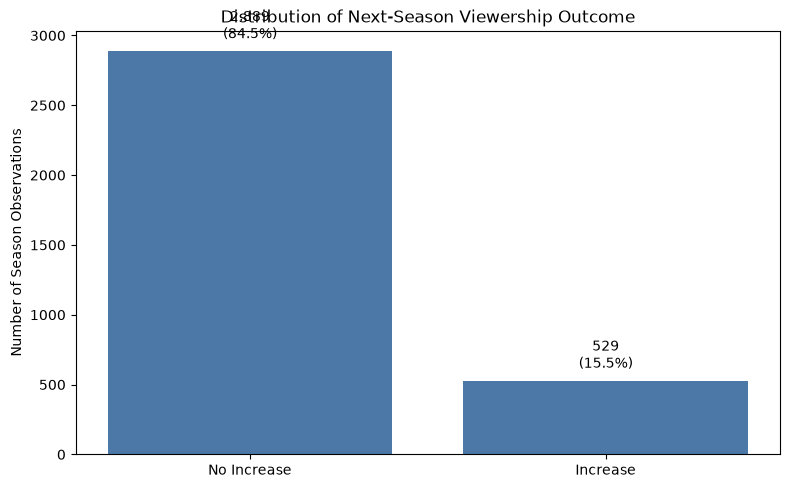

In [ ]:
plot_counts = pd.Series(
    [int(target_counts.get(0, 0)), int(target_counts.get(1, 0))],
    index=["No Increase", "Increase"],
)

fig, ax = plt.subplots(figsize=(8, 5))
draw_labeled_bar(ax, plot_counts, percent_denominator=len(modeling_df))
ax.set_title("Distribution of Next-Season Viewership Outcome")
ax.set_xlabel("")
ax.set_ylabel("Number of Season Observations")
plt.tight_layout()
plt.show()


## 5. Missing-Data Analysis


In [ ]:
predictor_missing_df = pd.DataFrame({
    "feature": predictor_cols,
    "missing_count": predictor_df[predictor_cols].isna().sum().values,
})
predictor_missing_df["non_missing_count"] = len(modeling_df) - predictor_missing_df["missing_count"]
predictor_missing_df["missing_percent"] = predictor_missing_df["missing_count"] / len(modeling_df) * 100
predictor_missing_df = predictor_missing_df.sort_values(["missing_percent", "missing_count"], ascending=False).reset_index(drop=True)
display(predictor_missing_df)

high_missingness_summary = pd.DataFrame({
    "threshold": ["> 30%", "> 50%", "> 80%"],
    "feature_count": [
        int((predictor_missing_df["missing_percent"] > 30).sum()),
        int((predictor_missing_df["missing_percent"] > 50).sum()),
        int((predictor_missing_df["missing_percent"] > 80).sum()),
    ],
})
display(high_missingness_summary)


,feature,missing_count,non_missing_count,missing_percent
0,imdb_age_at_netflix_year,3112,306,91.0474
1,netflix_imdb_year_gap,3112,306,91.0474
2,netflix_reference_year,3112,306,91.0474
3,prev_view_change_absolute,2126,1292,62.2001
4,prev_view_change_percent,2126,1292,62.2001
5,prev_hours_change_absolute,2102,1316,61.4980
6,prev_hours_change_percent,2102,1316,61.4980
7,prev_season_views,1390,2028,40.6671
8,prev_season_rating,1370,2048,40.0819
9,prev_season_hours,1369,2049,40.0527


,threshold,feature_count
0,> 30%,10
1,> 50%,7
2,> 80%,3


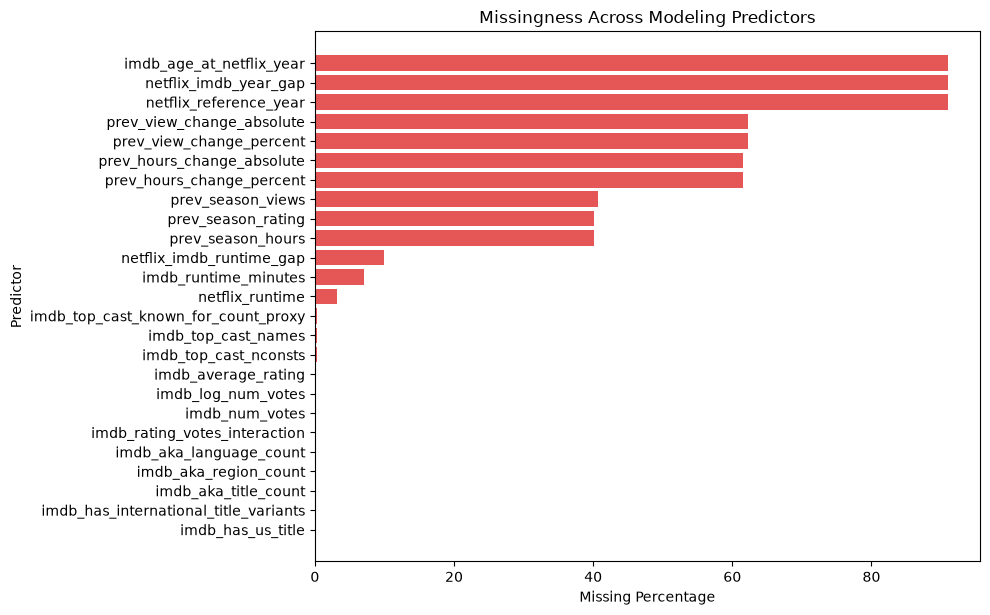

In [ ]:
missing_plot_df = predictor_missing_df.loc[predictor_missing_df["missing_count"] > 0].copy()

if missing_plot_df.empty:
    print("No predictor columns have missing values.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_plot_df) * 0.25)))
    ax.barh(missing_plot_df["feature"], missing_plot_df["missing_percent"], color="#E45756")
    ax.set_title("Missingness Across Modeling Predictors")
    ax.set_xlabel("Missing Percentage")
    ax.set_ylabel("Predictor")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


Features with elevated missingness will likely require different treatments depending on the modeling approach. Low to moderate missingness may be suitable for imputation, while very high missingness can justify exclusion or careful sensitivity analysis. Missingness flags can also be informative if the absence itself carries signal.


## 6. Constant and Near-Constant Predictors


In [ ]:
constant_features_df = pd.DataFrame({
    "feature": predictor_cols,
    "nunique_including_nan": [predictor_df[col].nunique(dropna=False) for col in predictor_cols],
    "nunique_excluding_nan": [predictor_df[col].nunique(dropna=True) for col in predictor_cols],
})
constant_features_df = constant_features_df.loc[constant_features_df["nunique_excluding_nan"] <= 1].sort_values("feature").reset_index(drop=True)
display(constant_features_df)

near_constant_rows = []
for col in predictor_cols:
    value_distribution = predictor_df[col].value_counts(normalize=True, dropna=False)
    top_share = float(value_distribution.iloc[0]) if not value_distribution.empty else np.nan
    if predictor_df[col].nunique(dropna=True) <= 5 and pd.notna(top_share) and top_share >= 0.95:
        near_constant_rows.append({
            "feature": col,
            "nunique_excluding_nan": predictor_df[col].nunique(dropna=True),
            "most_common_share": top_share,
        })

near_constant_df = pd.DataFrame(near_constant_rows)
if near_constant_df.empty:
    near_constant_df = pd.DataFrame(columns=["feature", "nunique_excluding_nan", "most_common_share"])
else:
    near_constant_df = near_constant_df.sort_values(["most_common_share", "feature"], ascending=[False, True]).reset_index(drop=True)
display(near_constant_df)

print("Recommendation: exclude constant predictors from model training because they contain no predictive information.")


,feature,nunique_including_nan,nunique_excluding_nan
0,imdb_director_credit_count,1,1
1,imdb_is_adult,1,1
2,imdb_movie_flag,1,1
3,imdb_series_flag,1,1
4,missing_cast_features,1,1


,feature,nunique_excluding_nan,most_common_share
0,imdb_director_credit_count,1,1.0000
1,imdb_is_adult,1,1.0000
2,imdb_movie_flag,1,1.0000
3,imdb_series_flag,1,1.0000
4,missing_cast_features,1,1.0000
5,imdb_started_before_netflix_flag,2,0.9991
6,missing_imdb_average_rating,2,0.9985
7,missing_imdb_num_votes,2,0.9985
8,imdb_miniseries_flag,2,0.9956
9,imdb_title_type,2,0.9956


Recommendation: exclude constant predictors from model training because they contain no predictive information.


## 7. Predictor Distribution and Skewness


In [ ]:
numeric_skew_df = pd.DataFrame({
    "feature": numeric_predictors,
    "skewness": [predictor_df[col].dropna().skew() for col in numeric_predictors],
})
numeric_skew_df["abs_skewness"] = numeric_skew_df["skewness"].abs()
numeric_skew_df["interpretation"] = pd.cut(
    numeric_skew_df["abs_skewness"],
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["fairly symmetric", "moderately skewed", "strongly skewed"],
)
numeric_skew_df = numeric_skew_df.sort_values("abs_skewness", ascending=False).reset_index(drop=True)
display(numeric_skew_df.head(20))

spotlight_features = [
    "netflix_views",
    "netflix_hours_viewed",
    "netflix_log_views",
    "netflix_log_hours",
    "imdb_num_votes",
    "imdb_log_num_votes",
]
display(numeric_skew_df[numeric_skew_df["feature"].isin([c for c in spotlight_features if c in numeric_skew_df["feature"].values])])


,feature,skewness,abs_skewness,interpretation
0,prev_hours_change_percent,34.8787,34.8787,strongly skewed
1,imdb_started_before_netflix_flag,33.7244,33.7244,strongly skewed
2,missing_imdb_num_votes,26.0998,26.0998,strongly skewed
3,missing_imdb_average_rating,26.0998,26.0998,strongly skewed
4,imdb_miniseries_flag,15.0023,15.0023,strongly skewed
5,imdb_has_international_title_variants,-13.6729,13.6729,strongly skewed
6,prev_view_change_percent,12.7922,12.7922,strongly skewed
7,imdb_age_at_netflix_year,9.9995,9.9995,strongly skewed
8,netflix_imdb_year_gap,9.9995,9.9995,strongly skewed
9,imdb_top_cast_count_used,-8.9129,8.9129,strongly skewed


,feature,skewness,abs_skewness,interpretation
16,imdb_num_votes,5.3761,5.3761,strongly skewed
19,netflix_views,4.7587,4.7587,strongly skewed
20,netflix_hours_viewed,4.6840,4.6840,strongly skewed
62,imdb_log_num_votes,-0.2539,0.2539,fairly symmetric
63,netflix_log_hours,-0.1062,0.1062,fairly symmetric
66,netflix_log_views,-0.0343,0.0343,fairly symmetric


## 8. Raw vs Log Viewership Distributions


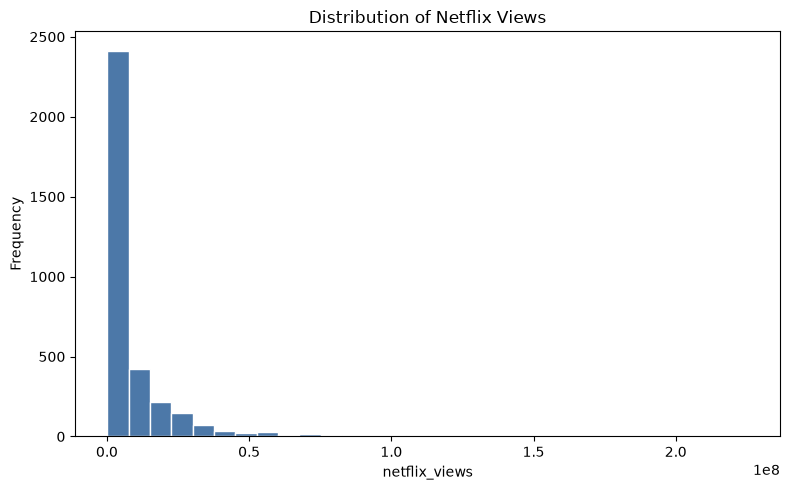

In [ ]:
if "netflix_views" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["netflix_views"].dropna(), bins=30, color="#4C78A8", edgecolor="white")
    ax.set_title("Distribution of Netflix Views")
    ax.set_xlabel("netflix_views")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column netflix_views is not present.")


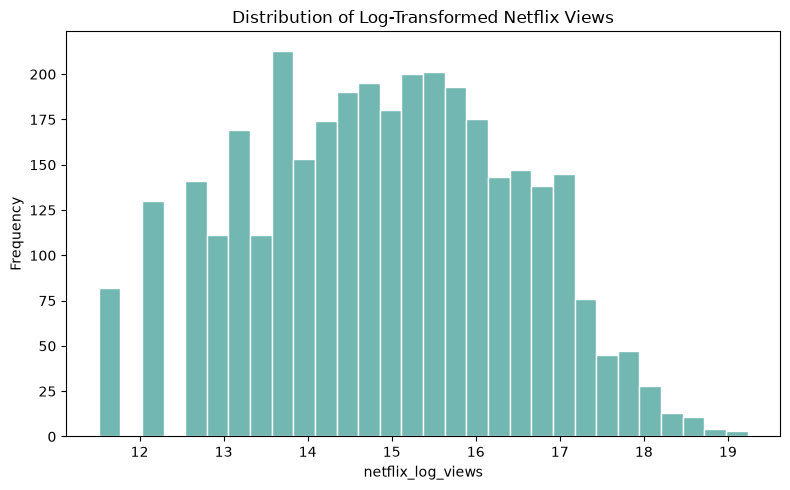

In [ ]:
if "netflix_log_views" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["netflix_log_views"].dropna(), bins=30, color="#72B7B2", edgecolor="white")
    ax.set_title("Distribution of Log-Transformed Netflix Views")
    ax.set_xlabel("netflix_log_views")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column netflix_log_views is not present.")


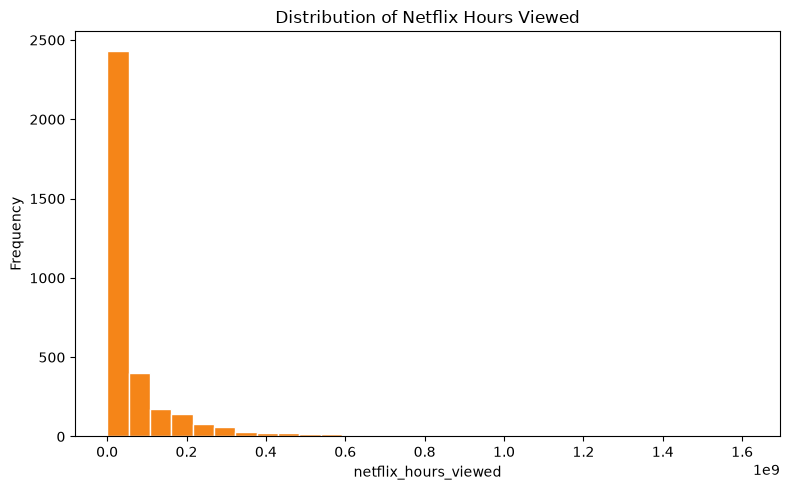

In [ ]:
if "netflix_hours_viewed" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["netflix_hours_viewed"].dropna(), bins=30, color="#F58518", edgecolor="white")
    ax.set_title("Distribution of Netflix Hours Viewed")
    ax.set_xlabel("netflix_hours_viewed")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column netflix_hours_viewed is not present.")


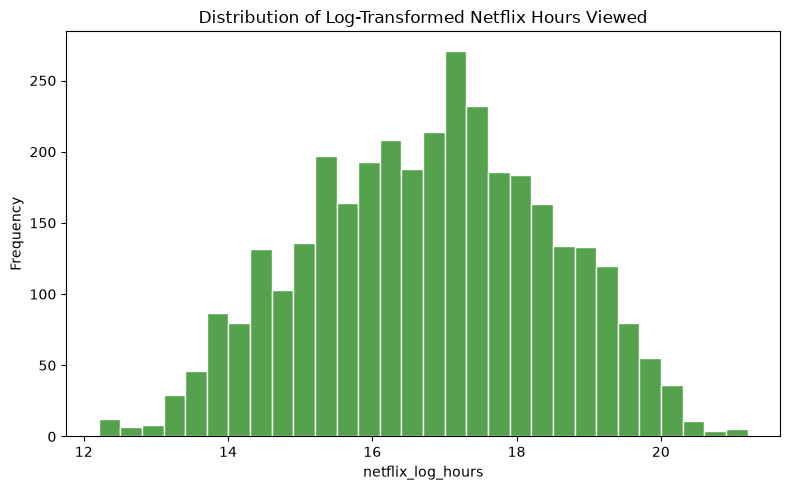

In [ ]:
if "netflix_log_hours" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["netflix_log_hours"].dropna(), bins=30, color="#54A24B", edgecolor="white")
    ax.set_title("Distribution of Log-Transformed Netflix Hours Viewed")
    ax.set_xlabel("netflix_log_hours")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column netflix_log_hours is not present.")


Raw viewership measures often exhibit strong right-skew because a small number of seasons receive exceptionally large audiences. The log-transformed versions should be compared directly to assess whether the transformation reduces skewness and produces a distribution that is easier for linear models to handle.


## 9. IMDb Vote Distribution


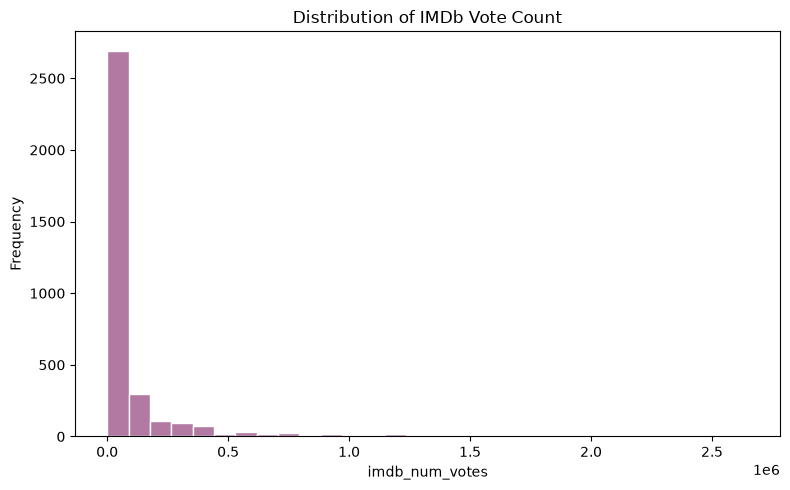

In [ ]:
if "imdb_num_votes" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["imdb_num_votes"].dropna(), bins=30, color="#B279A2", edgecolor="white")
    ax.set_title("Distribution of IMDb Vote Count")
    ax.set_xlabel("imdb_num_votes")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column imdb_num_votes is not present.")


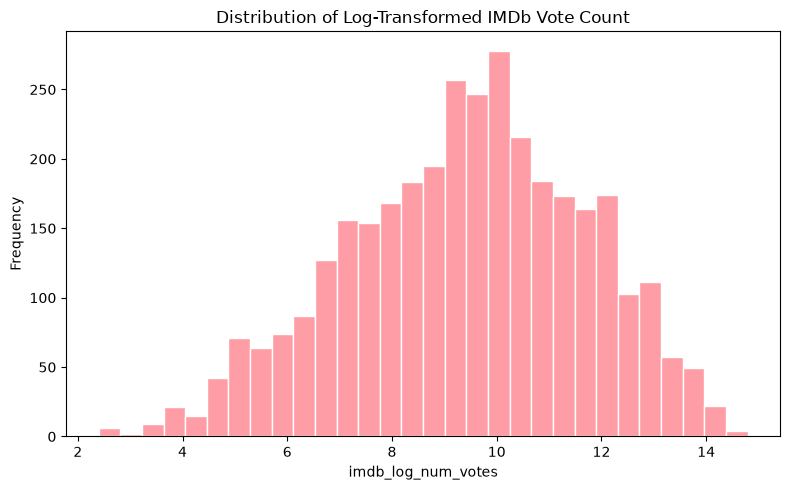

In [ ]:
if "imdb_log_num_votes" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["imdb_log_num_votes"].dropna(), bins=30, color="#FF9DA6", edgecolor="white")
    ax.set_title("Distribution of Log-Transformed IMDb Vote Count")
    ax.set_xlabel("imdb_log_num_votes")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column imdb_log_num_votes is not present.")


## 10. Numeric Predictor-to-Target Correlation


In [ ]:
numeric_target_corr_rows = []
target_numeric = modeling_df[TARGET_COLUMN]

for col in numeric_predictors:
    subset = modeling_df[[col, TARGET_COLUMN]].dropna()
    if subset.empty or subset[col].nunique() <= 1:
        pearson_corr = np.nan
        spearman_corr = np.nan
    else:
        pearson_corr = subset[col].corr(subset[TARGET_COLUMN], method="pearson")
        spearman_corr = subset[col].corr(subset[TARGET_COLUMN], method="spearman")
    numeric_target_corr_rows.append({
        "feature": col,
        "pearson_correlation": pearson_corr,
        "spearman_correlation": spearman_corr,
    })

numeric_target_corr_df = pd.DataFrame(numeric_target_corr_rows)
numeric_target_corr_df["abs_pearson"] = numeric_target_corr_df["pearson_correlation"].abs()
numeric_target_corr_df["abs_spearman"] = numeric_target_corr_df["spearman_correlation"].abs()
numeric_target_corr_df["max_abs_correlation"] = numeric_target_corr_df[["abs_pearson", "abs_spearman"]].max(axis=1)
numeric_target_corr_df = numeric_target_corr_df.sort_values(["max_abs_correlation", "feature"], ascending=[False, True]).reset_index(drop=True)
display(numeric_target_corr_df.head(20))

display(Markdown(
    """        Because the target is binary (`0`/`1`), Pearson correlation with the target can be interpreted as a point-biserial relationship. These correlations are useful for screening linear association, but they do **not** imply causation and should not replace cross-validated model evaluation.
"""
))


,feature,pearson_correlation,spearman_correlation,abs_pearson,abs_spearman,max_abs_correlation
0,imdb_self_count,0.2057,0.2475,0.2057,0.2475,0.2475
1,genre_drama,-0.1923,-0.1923,0.1923,0.1923,0.1923
2,genre_documentary,0.1875,0.1875,0.1875,0.1875,0.1875
3,is_documentary,0.1875,0.1875,0.1875,0.1875,0.1875
4,imdb_top_cast_known_for_count_proxy,-0.1443,-0.1102,0.1443,0.1102,0.1443
5,imdb_director_count,-0.1226,-0.1307,0.1226,0.1307,0.1307
6,netflix_runtime,-0.1198,-0.1198,0.1198,0.1198,0.1198
7,imdb_log_num_votes,-0.1044,-0.1152,0.1044,0.1152,0.1152
8,imdb_num_votes,-0.0273,-0.1152,0.0273,0.1152,0.1152
9,netflix_imdb_runtime_gap,-0.1122,-0.1097,0.1122,0.1097,0.1122


        Because the target is binary (`0`/`1`), Pearson correlation with the target can be interpreted as a point-biserial relationship. These correlations are useful for screening linear association, but they do **not** imply causation and should not replace cross-validated model evaluation.


## 11. Predictor-Target Correlation Bar Chart


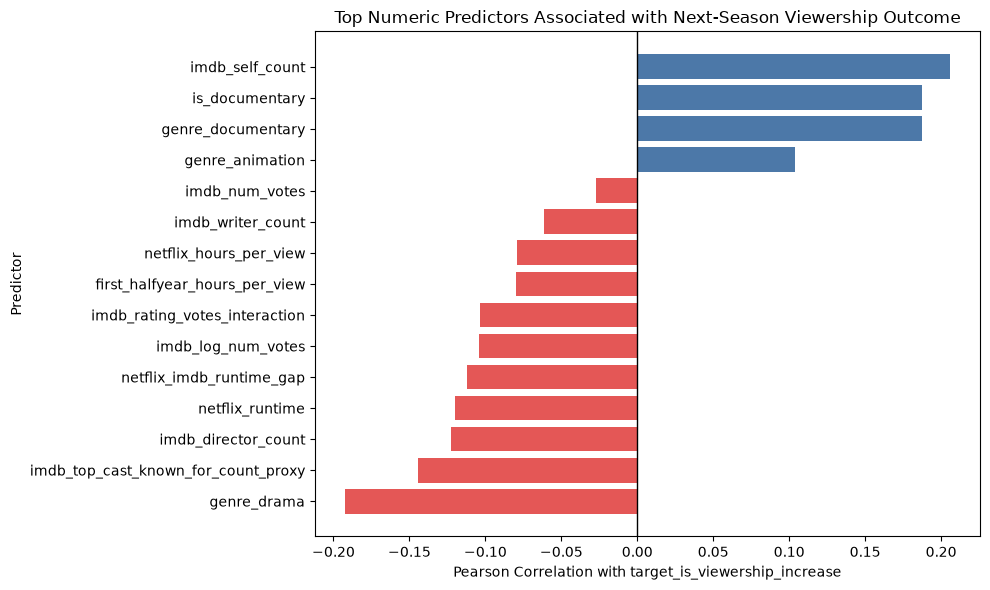

In [ ]:
corr_plot_df = numeric_target_corr_df.head(15).sort_values("pearson_correlation")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E45756" if x < 0 else "#4C78A8" for x in corr_plot_df["pearson_correlation"]]
ax.barh(corr_plot_df["feature"], corr_plot_df["pearson_correlation"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top Numeric Predictors Associated with Next-Season Viewership Outcome")
ax.set_xlabel("Pearson Correlation with target_is_viewership_increase")
ax.set_ylabel("Predictor")
plt.tight_layout()
plt.show()


## 12. Correlation Heatmap


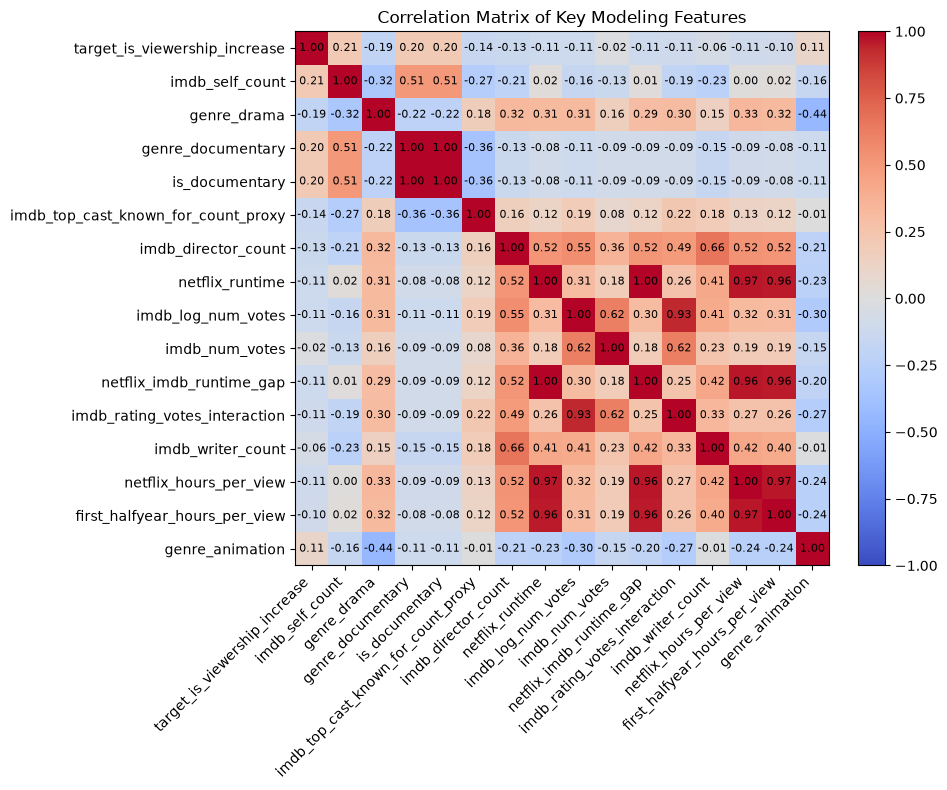

In [ ]:
heatmap_features = [TARGET_COLUMN] + numeric_target_corr_df["feature"].head(15).tolist()
heatmap_features = [col for col in heatmap_features if col in modeling_df.columns]
heatmap_df = modeling_df[heatmap_features].dropna()

if heatmap_df.empty:
    print("Not enough complete data to build the key-feature correlation matrix.")
else:
    _ = make_corr_matrix_plot(heatmap_df, "Correlation Matrix of Key Modeling Features")
    plt.show()


## 13. Highly Correlated Predictor Pairs


In [ ]:
numeric_corr_matrix = predictor_df[numeric_predictors].corr().abs()
high_corr_pairs = []

for i, col_1 in enumerate(numeric_corr_matrix.columns):
    for col_2 in numeric_corr_matrix.columns[i + 1:]:
        corr_value = predictor_df[[col_1, col_2]].corr().iloc[0, 1]
        if pd.notna(corr_value) and abs(corr_value) >= 0.90:
            high_corr_pairs.append({
                "feature_1": col_1,
                "feature_2": col_2,
                "correlation": corr_value,
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)
if high_corr_pairs_df.empty:
    high_corr_pairs_df = pd.DataFrame(columns=["feature_1", "feature_2", "correlation"])
else:
    high_corr_pairs_df = high_corr_pairs_df.sort_values("correlation", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
display(high_corr_pairs_df)

display(Markdown(
    """        Highly correlated predictor pairs can create redundancy and unstable coefficient estimates, especially for logistic regression and other linear models. Raw versus transformed versions of the same variable, mirrored binary flags, and engineered derivatives are common sources of multicollinearity.
"""
))


,feature_1,feature_2,correlation
0,genre_documentary,is_documentary,1.0000
1,genre_animation,is_animation,1.0000
2,imdb_started_before_netflix_flag,netflix_imdb_year_gap,1.0000
3,imdb_average_rating,prev_season_rating,1.0000
4,imdb_age_at_netflix_year,imdb_started_before_netflix_flag,1.0000
5,imdb_age_at_netflix_year,netflix_imdb_year_gap,1.0000
6,missing_imdb_average_rating,missing_imdb_num_votes,1.0000
7,season_is_first,season_is_later,-1.0000
8,imdb_same_year_as_netflix_flag,netflix_imdb_year_gap,-1.0000
9,imdb_age_at_netflix_year,imdb_same_year_as_netflix_flag,-1.0000


        Highly correlated predictor pairs can create redundancy and unstable coefficient estimates, especially for logistic regression and other linear models. Raw versus transformed versions of the same variable, mirrored binary flags, and engineered derivatives are common sources of multicollinearity.


## 14. Runtime vs Hours-per-View Analysis


In [ ]:
if {"netflix_runtime", "netflix_hours_per_view"}.issubset(modeling_df.columns):
    runtime_hours_df = modeling_df[["netflix_runtime", "netflix_hours_per_view"]].dropna()
    pearson_runtime_hours = runtime_hours_df["netflix_runtime"].corr(runtime_hours_df["netflix_hours_per_view"], method="pearson")
    spearman_runtime_hours = runtime_hours_df["netflix_runtime"].corr(runtime_hours_df["netflix_hours_per_view"], method="spearman")
    print(f"Pearson correlation: {pearson_runtime_hours:.4f}")
    print(f"Spearman correlation: {spearman_runtime_hours:.4f}")
else:
    print("Required columns for runtime vs hours-per-view are not present.")


Pearson correlation: 0.9654
Spearman correlation: 0.9815


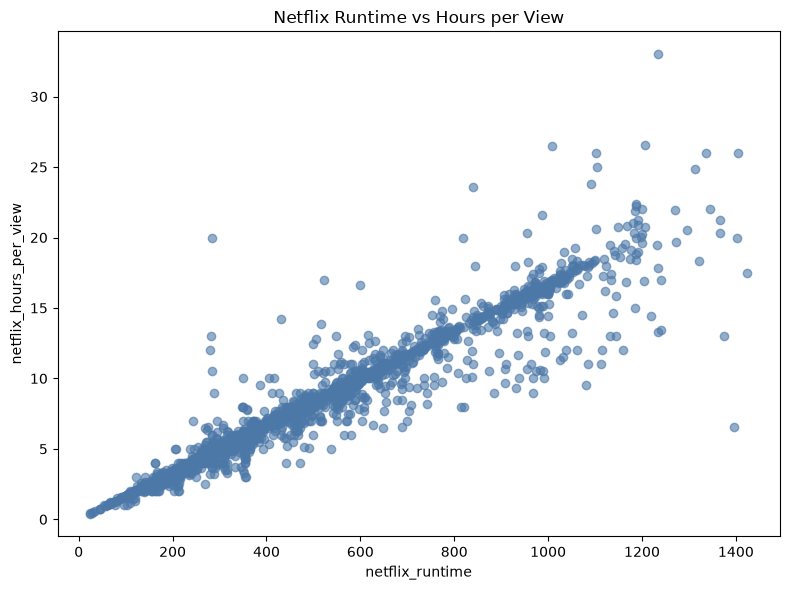

In [ ]:
if {"netflix_runtime", "netflix_hours_per_view"}.issubset(modeling_df.columns):
    plot_df = modeling_df[["netflix_runtime", "netflix_hours_per_view"]].dropna()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(plot_df["netflix_runtime"], plot_df["netflix_hours_per_view"], alpha=0.6, color="#4C78A8")
    ax.set_title("Netflix Runtime vs Hours per View")
    ax.set_xlabel("netflix_runtime")
    ax.set_ylabel("netflix_hours_per_view")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for runtime vs hours-per-view are not present.")


In [ ]:
if {"netflix_runtime", "first_halfyear_hours_per_view"}.issubset(modeling_df.columns):
    halfyear_runtime_df = modeling_df[["netflix_runtime", "first_halfyear_hours_per_view"]].dropna()
    summary = pd.DataFrame({
        "metric": ["pearson", "spearman"],
        "correlation": [
            halfyear_runtime_df["netflix_runtime"].corr(halfyear_runtime_df["first_halfyear_hours_per_view"], method="pearson"),
            halfyear_runtime_df["netflix_runtime"].corr(halfyear_runtime_df["first_halfyear_hours_per_view"], method="spearman"),
        ],
    })
    display(summary)
else:
    print("Optional column first_halfyear_hours_per_view is not present for the runtime comparison table.")


,metric,correlation
0,pearson,0.9562
1,spearman,0.9692


## 15. Current-Season vs Next-Season Viewership


In [ ]:
if {"netflix_log_views", "target_next_season_views"}.issubset(modeling_df.columns):
    current_next_df = modeling_df[["netflix_log_views", "target_next_season_views"]].dropna().copy()
    current_next_df["target_next_season_log_views"] = np.log1p(current_next_df["target_next_season_views"])
    pearson_current_next = current_next_df["netflix_log_views"].corr(current_next_df["target_next_season_log_views"], method="pearson")
    spearman_current_next = current_next_df["netflix_log_views"].corr(current_next_df["target_next_season_log_views"], method="spearman")
    print(f"Pearson correlation: {pearson_current_next:.4f}")
    print(f"Spearman correlation: {spearman_current_next:.4f}")
else:
    print("Columns needed for current-season vs next-season viewership analysis are not present.")


Pearson correlation: 0.9530
Spearman correlation: 0.9556


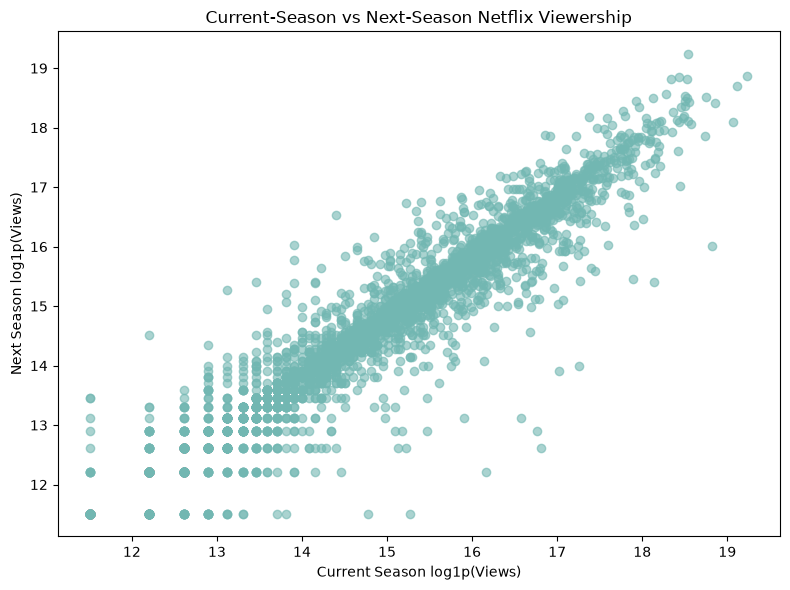

In [ ]:
if {"netflix_log_views", "target_next_season_views"}.issubset(modeling_df.columns):
    plot_df = modeling_df[["netflix_log_views", "target_next_season_views"]].dropna().copy()
    plot_df["target_next_season_log_views"] = np.log1p(plot_df["target_next_season_views"])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(plot_df["netflix_log_views"], plot_df["target_next_season_log_views"], alpha=0.6, color="#72B7B2")
    ax.set_title("Current-Season vs Next-Season Netflix Viewership")
    ax.set_xlabel("Current Season log1p(Views)")
    ax.set_ylabel("Next Season log1p(Views)")
    plt.tight_layout()
    plt.show()
else:
    print("Columns needed for current-season vs next-season viewership analysis are not present.")


This project distinguishes between predicting **absolute next-season viewership** and predicting **whether viewership increases**. A feature can be strongly associated with the level of next-season viewership without necessarily being equally informative for the binary growth outcome.


## 16. IMDb Rating vs Target


In [ ]:
if "imdb_average_rating" in modeling_df.columns:
    rating_group_summary = modeling_df.groupby(TARGET_COLUMN)["imdb_average_rating"].agg(["mean", "median", "count"])
    rating_group_summary.index = rating_group_summary.index.map(outcome_label)
    display(rating_group_summary)
else:
    print("Column imdb_average_rating is not present.")


,mean,median,count
target_is_viewership_increase,,,
No Increase,7.4458,7.6000,2884
Increase,7.2327,7.4000,529


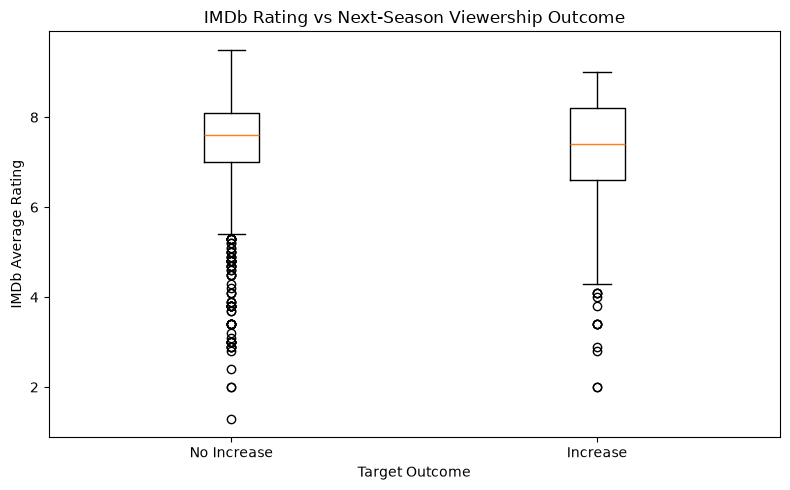

In [ ]:
if "imdb_average_rating" in modeling_df.columns:
    box_data = [
        modeling_df.loc[modeling_df[TARGET_COLUMN] == 0, "imdb_average_rating"].dropna(),
        modeling_df.loc[modeling_df[TARGET_COLUMN] == 1, "imdb_average_rating"].dropna(),
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(box_data, tick_labels=["No Increase", "Increase"])
    ax.set_title("IMDb Rating vs Next-Season Viewership Outcome")
    ax.set_xlabel("Target Outcome")
    ax.set_ylabel("IMDb Average Rating")
    plt.tight_layout()
    plt.show()
else:
    print("Column imdb_average_rating is not present.")


## 17. Current Viewership vs Classification Target


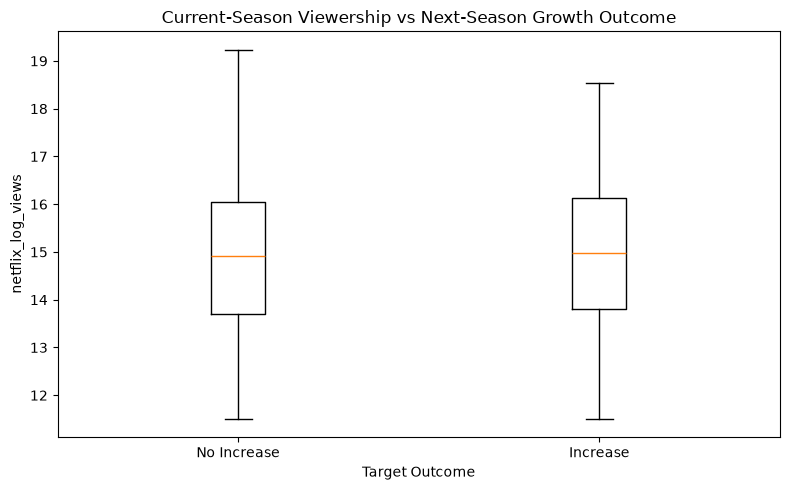

In [ ]:
if "netflix_log_views" in modeling_df.columns:
    box_data = [
        modeling_df.loc[modeling_df[TARGET_COLUMN] == 0, "netflix_log_views"].dropna(),
        modeling_df.loc[modeling_df[TARGET_COLUMN] == 1, "netflix_log_views"].dropna(),
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(box_data, tick_labels=["No Increase", "Increase"])
    ax.set_title("Current-Season Viewership vs Next-Season Growth Outcome")
    ax.set_xlabel("Target Outcome")
    ax.set_ylabel("netflix_log_views")
    plt.tight_layout()
    plt.show()
else:
    print("Column netflix_log_views is not present.")


## 18. Genre Analysis


In [ ]:
genre_candidate_cols = [
    col for col in predictor_cols
    if col.startswith("genre_") and col != "genre_count"
]
preferred_genres = [
    "genre_drama", "genre_comedy", "genre_action", "genre_thriller", "genre_crime",
    "genre_romance", "genre_animation", "genre_documentary", "genre_fantasy",
    "genre_horror", "genre_sci_fi", "genre_family",
]
genre_cols = [col for col in preferred_genres if col in genre_candidate_cols] + [col for col in genre_candidate_cols if col not in preferred_genres]
genre_cols = list(dict.fromkeys(genre_cols))

genre_rows = []
for col in genre_cols:
    subset = modeling_df.loc[modeling_df[col] == 1, [col, TARGET_COLUMN]]
    genre_rows.append({
        "genre_feature": col,
        "observation_count": len(subset),
        "increase_count": int(subset[TARGET_COLUMN].sum()),
        "increase_rate": subset[TARGET_COLUMN].mean() if len(subset) else np.nan,
    })

genre_summary_df = pd.DataFrame(genre_rows).sort_values(["increase_rate", "observation_count"], ascending=[False, False]).reset_index(drop=True)
display(genre_summary_df)


,genre_feature,observation_count,increase_count,increase_rate
0,genre_documentary,171,77,0.4503
1,genre_family,242,62,0.2562
2,genre_animation,737,167,0.2266
3,genre_romance,384,62,0.1615
4,genre_comedy,1391,200,0.1438
5,genre_action,651,82,0.1260
6,genre_crime,638,66,0.1034
7,genre_drama,1679,141,0.0840
8,genre_fantasy,153,11,0.0719
9,genre_thriller,157,10,0.0637


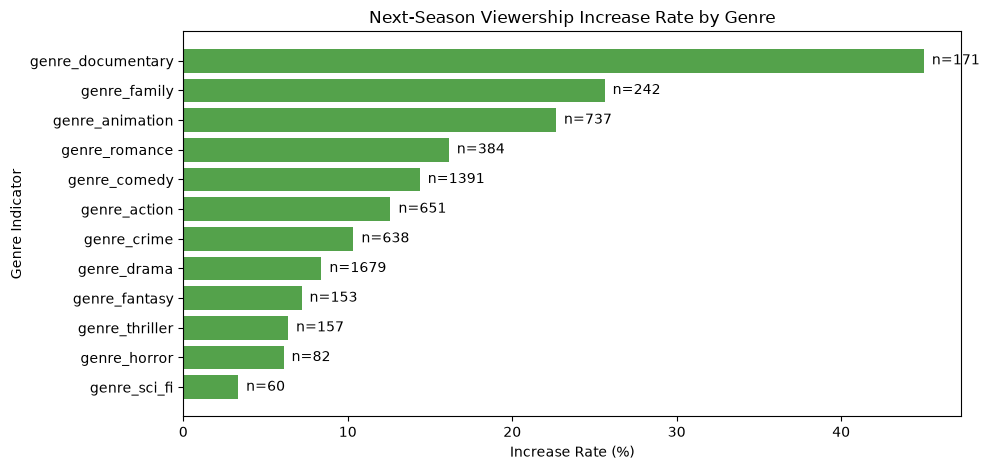

In [ ]:
if "genre_summary_df" in globals() and not genre_summary_df.empty:
    min_genre_n = 20
    genre_plot_df = genre_summary_df.loc[genre_summary_df["observation_count"] >= min_genre_n].sort_values("increase_rate")
    if genre_plot_df.empty:
        print(f"No genre indicators met the minimum sample size threshold of {min_genre_n}.")
    else:
        fig, ax = plt.subplots(figsize=(10, max(4, len(genre_plot_df) * 0.4)))
        ax.barh(genre_plot_df["genre_feature"], genre_plot_df["increase_rate"] * 100, color="#54A24B")
        ax.set_title("Next-Season Viewership Increase Rate by Genre")
        ax.set_xlabel("Increase Rate (%)")
        ax.set_ylabel("Genre Indicator")
        for idx, row in genre_plot_df.reset_index(drop=True).iterrows():
            ax.text(row["increase_rate"] * 100, idx, f"  n={int(row['observation_count'])}", va="center")
        plt.tight_layout()
        plt.show()
else:
    print("No genre indicator columns were available for analysis.")


Genre relationships should be treated as descriptive rather than causal. Differences in increase rate may partly reflect release strategy, franchise effects, sample composition, or other variables that co-vary with genre.


## 19. Season Number Analysis


In [ ]:
season_col = "netflix_season_number" if "netflix_season_number" in modeling_df.columns else ("season_order" if "season_order" in modeling_df.columns else None)
if season_col is None:
    print("No season-number field is present for season-order analysis.")
else:
    season_summary_df = (
        modeling_df
        .groupby(season_col)[TARGET_COLUMN]
        .agg(observation_count="count", increase_count="sum", increase_rate="mean")
        .reset_index()
        .sort_values(season_col)
    )
    display(season_summary_df)


,netflix_season_number,observation_count,increase_count,increase_rate
0,1,1298,157,0.1210
1,2,716,109,0.1522
2,3,430,74,0.1721
3,4,289,57,0.1972
4,5,192,37,0.1927
5,6,135,23,0.1704
6,7,86,10,0.1163
7,8,54,8,0.1481
8,9,36,10,0.2778
9,10,31,5,0.1613


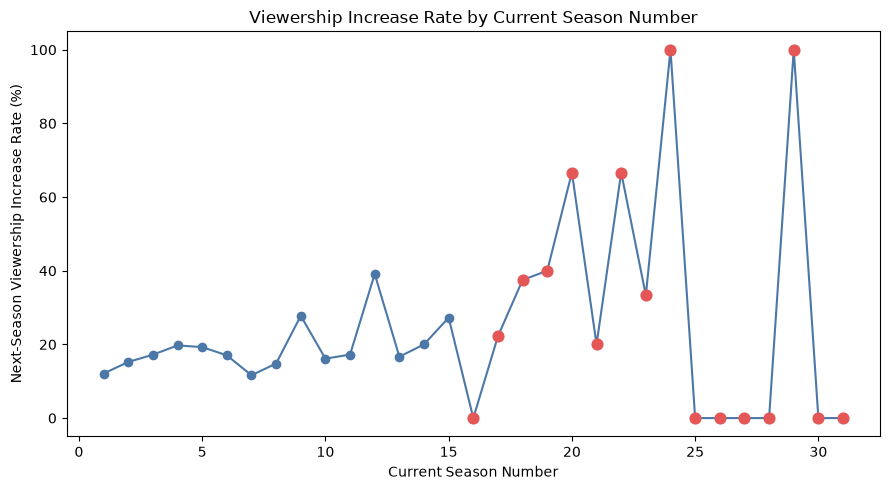

In [ ]:
if "season_summary_df" in globals():
    plot_df = season_summary_df.copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(plot_df[season_col], plot_df["increase_rate"] * 100, marker="o", color="#4C78A8")
    for _, row in plot_df.iterrows():
        if row["observation_count"] < 10:
            ax.scatter(row[season_col], row["increase_rate"] * 100, color="#E45756", s=60, zorder=3)
    ax.set_title("Viewership Increase Rate by Current Season Number")
    ax.set_xlabel("Current Season Number")
    ax.set_ylabel("Next-Season Viewership Increase Rate (%)")
    plt.tight_layout()
    plt.show()
else:
    print("Season summary table is not available.")


## 20. First-Observed Half-Year Feature Analysis


In [ ]:
halfyear_numeric_cols = [
    col for col in [
        "first_observed_halfyear_views",
        "first_observed_halfyear_hours",
        "first_halfyear_hours_per_view",
    ]
    if col in modeling_df.columns
]
halfyear_period_col = "first_observed_halfyear_period" if "first_observed_halfyear_period" in modeling_df.columns else None

if halfyear_numeric_cols:
    halfyear_numeric_summary_rows = []
    for col in halfyear_numeric_cols:
        series = modeling_df[col]
        valid = modeling_df[[col, TARGET_COLUMN]].dropna()
        halfyear_numeric_summary_rows.append({
            "feature": col,
            "missing_count": int(series.isna().sum()),
            "missing_percent": float(series.isna().mean() * 100),
            "mean": float(series.mean()),
            "median": float(series.median()),
            "std": float(series.std()),
            "min": float(series.min()),
            "max": float(series.max()),
            "skewness": float(series.dropna().skew()),
            "pearson_to_target": valid[col].corr(valid[TARGET_COLUMN], method="pearson") if not valid.empty and valid[col].nunique() > 1 else np.nan,
            "spearman_to_target": valid[col].corr(valid[TARGET_COLUMN], method="spearman") if not valid.empty and valid[col].nunique() > 1 else np.nan,
        })
    halfyear_numeric_summary_df = pd.DataFrame(halfyear_numeric_summary_rows)
    display(halfyear_numeric_summary_df)
else:
    print("Optional half-year numeric features are not present; skipping numeric half-year analysis.")


,feature,missing_count,missing_percent,mean,median,std,min,max,skewness,pearson_to_target,spearman_to_target
0,first_observed_halfyear_views,0,0.0000,"2,666,734.9327","900,000.0000","5,934,888.3351","100,000.0000","99,200,000.0000",6.9985,-0.0340,-0.0141
1,first_observed_halfyear_hours,0,0.0000,"18,995,787.0099","5,800,000.0000","43,810,920.7916","100,000.0000","812,100,000.0000",8.1399,-0.0430,-0.0569
2,first_halfyear_hours_per_view,0,0.0000,8.1443,7.0000,6.6507,0.4091,140.0000,6.8100,-0.0801,-0.1050


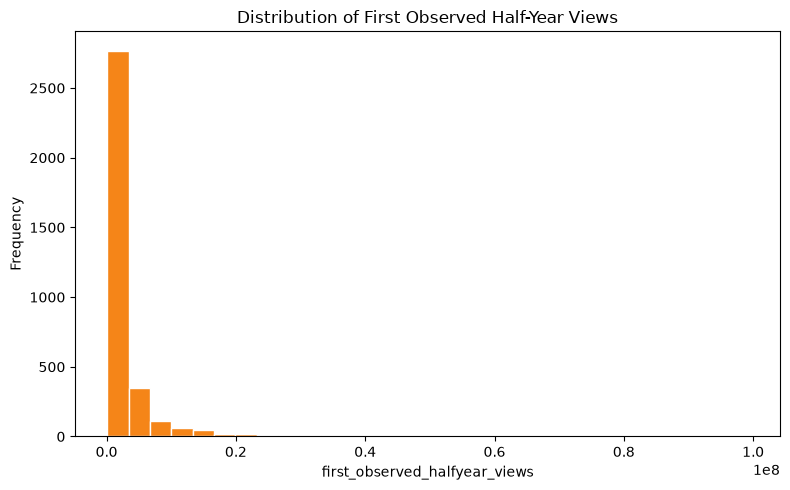

In [ ]:
if "first_observed_halfyear_views" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["first_observed_halfyear_views"].dropna(), bins=30, color="#F58518", edgecolor="white")
    ax.set_title("Distribution of First Observed Half-Year Views")
    ax.set_xlabel("first_observed_halfyear_views")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column first_observed_halfyear_views is not present.")


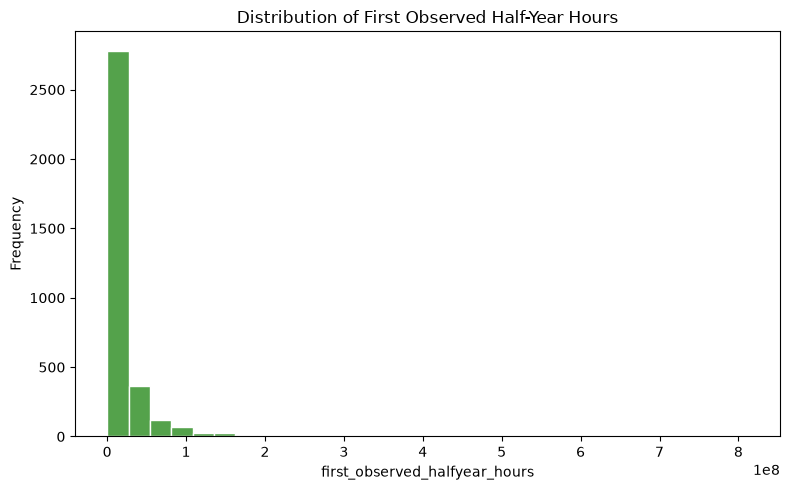

In [ ]:
if "first_observed_halfyear_hours" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["first_observed_halfyear_hours"].dropna(), bins=30, color="#54A24B", edgecolor="white")
    ax.set_title("Distribution of First Observed Half-Year Hours")
    ax.set_xlabel("first_observed_halfyear_hours")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column first_observed_halfyear_hours is not present.")


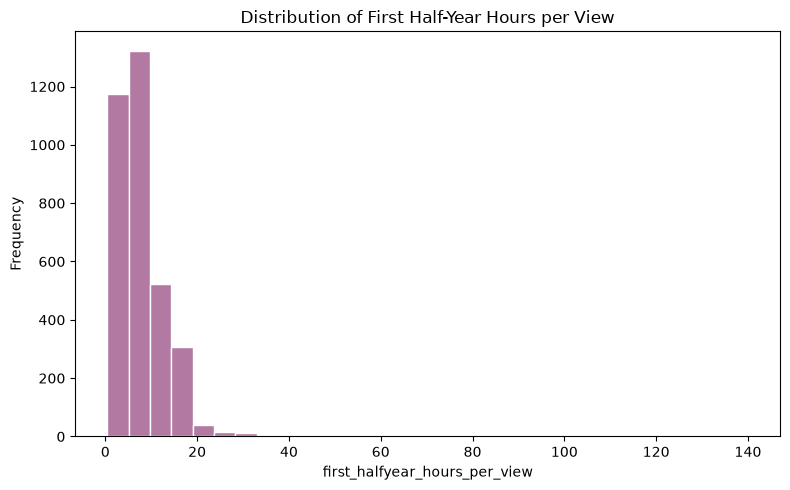

In [ ]:
if "first_halfyear_hours_per_view" in modeling_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(modeling_df["first_halfyear_hours_per_view"].dropna(), bins=30, color="#B279A2", edgecolor="white")
    ax.set_title("Distribution of First Half-Year Hours per View")
    ax.set_xlabel("first_halfyear_hours_per_view")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Column first_halfyear_hours_per_view is not present.")


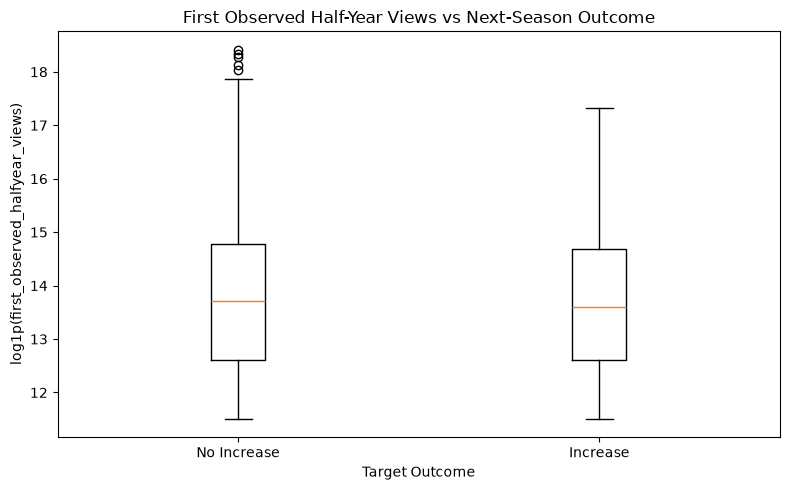

In [ ]:
if "first_observed_halfyear_views" in modeling_df.columns:
    halfyear_box_df = modeling_df[[TARGET_COLUMN, "first_observed_halfyear_views"]].dropna().copy()
    halfyear_box_df["log_first_observed_halfyear_views"] = np.log1p(halfyear_box_df["first_observed_halfyear_views"])
    box_data = [
        halfyear_box_df.loc[halfyear_box_df[TARGET_COLUMN] == 0, "log_first_observed_halfyear_views"],
        halfyear_box_df.loc[halfyear_box_df[TARGET_COLUMN] == 1, "log_first_observed_halfyear_views"],
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(box_data, tick_labels=["No Increase", "Increase"])
    ax.set_title("First Observed Half-Year Views vs Next-Season Outcome")
    ax.set_xlabel("Target Outcome")
    ax.set_ylabel("log1p(first_observed_halfyear_views)")
    plt.tight_layout()
    plt.show()
else:
    print("Column first_observed_halfyear_views is not present.")


In [ ]:
if halfyear_period_col is not None:
    halfyear_period_summary_df = (
        modeling_df
        .groupby(halfyear_period_col)[TARGET_COLUMN]
        .agg(observation_count="count", increase_count="sum", increase_rate="mean")
        .reset_index()
        .sort_values(halfyear_period_col)
    )
    display(halfyear_period_summary_df)
else:
    print("Column first_observed_halfyear_period is not present; skipping categorical half-year summary.")


,first_observed_halfyear_period,observation_count,increase_count,increase_rate
0,2023 H1,1993,419,0.2102
1,2023 H2,275,51,0.1855
2,2024 H1,297,13,0.0438
3,2024 H2,203,14,0.0690
4,2025 H1,187,17,0.0909
5,2025 H2,222,10,0.0450
6,2026 H1,241,5,0.0207


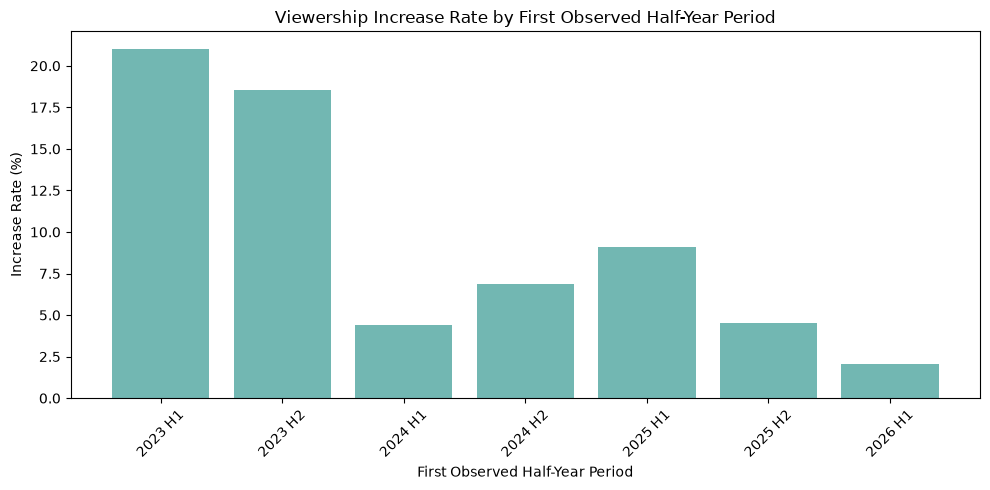

In [ ]:
if "halfyear_period_summary_df" in globals():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(halfyear_period_summary_df[halfyear_period_col], halfyear_period_summary_df["increase_rate"] * 100, color="#72B7B2")
    ax.set_title("Viewership Increase Rate by First Observed Half-Year Period")
    ax.set_xlabel("First Observed Half-Year Period")
    ax.set_ylabel("Increase Rate (%)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No half-year period summary is available for plotting.")


## 21. Categorical-Variable Statistical Tests


In [ ]:
categorical_test_candidates = [
    col for col in categorical_predictors
    if predictor_df[col].nunique(dropna=True) > 1 and predictor_df[col].nunique(dropna=False) <= 20
]
for binary_col in [
    "season_is_first", "season_is_later", "is_animation", "is_documentary",
    "is_kids_family_like", "has_prev_season_observation"
]:
    if binary_col in predictor_cols and binary_col not in categorical_test_candidates:
        categorical_test_candidates.append(binary_col)
if halfyear_period_col is not None and halfyear_period_col not in categorical_test_candidates:
    categorical_test_candidates.append(halfyear_period_col)

categorical_test_rows = []
for col in sorted(set(categorical_test_candidates)):
    table = pd.crosstab(modeling_df[col], modeling_df[TARGET_COLUMN], dropna=False)
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    categorical_test_rows.append({
        "variable": col,
        "chi_square": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v_from_table(table),
    })

categorical_test_df = pd.DataFrame(categorical_test_rows)
if categorical_test_df.empty:
    categorical_test_df = pd.DataFrame(columns=["variable", "chi_square", "p_value", "cramers_v"])
else:
    categorical_test_df = categorical_test_df.sort_values(["cramers_v", "chi_square"], ascending=[False, False]).reset_index(drop=True)
display(categorical_test_df)


,variable,chi_square,p_value,cramers_v
0,first_observed_halfyear_period,147.6006,0.0000,0.2036
1,is_documentary,117.8078,0.0000,0.1849
2,is_animation,36.3577,0.0000,0.1017
3,is_kids_family_like,31.9027,0.0000,0.0951
4,season_is_first,17.8765,0.0000,0.0703
5,season_is_later,17.8765,0.0000,0.0703
6,has_prev_season_observation,9.8680,0.0017,0.0509
7,imdb_title_type,0.0163,0.8984,0.0000


Statistical significance should not be treated as a direct substitute for predictive usefulness. Large samples can make weak effects appear statistically significant, so effect size and model validation remain important.


## 22. Missingness Indicators vs Target


In [ ]:
missing_indicator_cols = [col for col in predictor_cols if col.startswith("missing_")]
missing_indicator_rows = []
for col in missing_indicator_cols:
    for flag_value in [0, 1]:
        subset = modeling_df.loc[modeling_df[col] == flag_value, TARGET_COLUMN]
        missing_indicator_rows.append({
            "missing_indicator": col,
            "flag_value": flag_value,
            "observation_count": int(subset.shape[0]),
            "increase_rate": float(subset.mean()) if len(subset) else np.nan,
        })

missing_indicator_summary_df = pd.DataFrame(missing_indicator_rows)
display(missing_indicator_summary_df)


,missing_indicator,flag_value,observation_count,increase_rate
0,missing_cast_features,0,3418,0.1548
1,missing_cast_features,1,0,NaN
2,missing_imdb_average_rating,0,3413,0.1550
3,missing_imdb_average_rating,1,5,0.0000
4,missing_imdb_num_votes,0,3413,0.1550
5,missing_imdb_num_votes,1,5,0.0000
6,missing_netflix_imdb_runtime_gap,0,3078,0.1475
7,missing_netflix_imdb_runtime_gap,1,340,0.2206
8,missing_netflix_runtime,0,3307,0.1527
9,missing_netflix_runtime,1,111,0.2162


## 23. Multicollinearity / VIF


In [ ]:
vif_candidate_cols = []
excluded_prefixes = ("genre_", "missing_")
for col in numeric_predictors:
    if col in target_cols or col in identifier_cols:
        continue
    if col.startswith(excluded_prefixes):
        continue
    if predictor_df[col].nunique(dropna=True) <= 1:
        continue
    vif_candidate_cols.append(col)

vif_base_df = predictor_df[vif_candidate_cols].copy()
vif_base_df = vif_base_df.loc[:, ~vif_base_df.T.duplicated()]
vif_base_df = vif_base_df.fillna(vif_base_df.median(numeric_only=True))
vif_base_df = vif_base_df.loc[:, vif_base_df.nunique(dropna=True) > 1]

if vif_base_df.shape[1] < 2:
    print("Not enough stable numeric predictors were available for VIF analysis.")
    vif_df = pd.DataFrame(columns=["feature", "vif"])
else:
    vif_rows = []
    X = vif_base_df.astype(float)
    for i, col in enumerate(X.columns):
        vif_rows.append({
            "feature": col,
            "vif": variance_inflation_factor(X.values, i),
        })
    vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
    display(vif_df.head(25))


C:\Users\shrib\OneDrive\Study\Purdue\GRAD504\Group9\Netflix_Viewership_Group_9\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,vif
0,imdb_self_count,inf
1,imdb_principal_count,"9,007,199,254,740,992.0000"
2,imdb_actor_count,"9,007,199,254,740,992.0000"
3,imdb_actress_count,"1,501,199,875,790,165.2500"
4,imdb_writer_credit_count,"346,430,740,566,961.2500"
5,imdb_age_at_netflix_year,"160,842,843,834,660.5625"
6,imdb_producer_count,"21,809,199,164,021.7734"
7,imdb_started_before_netflix_flag,"378,374,259,808.4853"
8,season_is_later,"603,910.1886"
9,season_is_first,"369,650.9050"


Approximate VIF interpretation:

- `VIF < 5`: generally acceptable
- `5 to 10`: investigate
- `> 10`: strong multicollinearity concern

VIF is a diagnostic, not an automatic deletion rule.


## 24. Candidate Feature-Quality Table


In [ ]:
high_corr_feature_set = set(high_corr_pairs_df["feature_1"]).union(set(high_corr_pairs_df["feature_2"])) if "high_corr_pairs_df" in globals() and not high_corr_pairs_df.empty else set()
feature_quality_rows = []

corr_lookup = numeric_target_corr_df.set_index("feature") if "numeric_target_corr_df" in globals() else pd.DataFrame()
skew_lookup = numeric_skew_df.set_index("feature") if "numeric_skew_df" in globals() else pd.DataFrame()
constant_feature_set = set(constant_features_df["feature"]) if "constant_features_df" in globals() and not constant_features_df.empty else set()

for col in predictor_cols:
    feature_quality_rows.append({
        "feature": col,
        "dtype": str(modeling_df[col].dtype),
        "missing_percent": float(modeling_df[col].isna().mean() * 100),
        "unique_values": int(modeling_df[col].nunique(dropna=True)),
        "skewness": float(skew_lookup.loc[col, "skewness"]) if col in skew_lookup.index else np.nan,
        "pearson_to_target": float(corr_lookup.loc[col, "pearson_correlation"]) if col in corr_lookup.index else np.nan,
        "spearman_to_target": float(corr_lookup.loc[col, "spearman_correlation"]) if col in corr_lookup.index else np.nan,
        "constant_flag": col in constant_feature_set,
        "high_correlation_flag": col in high_corr_feature_set,
    })

feature_quality_df = pd.DataFrame(feature_quality_rows).sort_values(["high_correlation_flag", "missing_percent", "feature"], ascending=[False, False, True]).reset_index(drop=True)
display(feature_quality_df)


,feature,dtype,missing_percent,unique_values,skewness,pearson_to_target,spearman_to_target,constant_flag,high_correlation_flag
0,imdb_age_at_netflix_year,float64,91.0474,2,9.9995,0.0685,0.0685,False,True
1,netflix_imdb_year_gap,float64,91.0474,2,9.9995,0.0685,0.0685,False,True
2,prev_season_rating,float64,40.0819,57,-1.5925,-0.0485,-0.0314,False,True
3,prev_season_hours,float64,40.0527,1018,3.6331,0.0061,0.0002,False,True
4,netflix_imdb_runtime_gap,float64,9.9473,876,0.9337,-0.1122,-0.1097,False,True
5,netflix_runtime,float64,3.2475,938,0.9409,-0.1198,-0.1198,False,True
6,imdb_average_rating,float64,0.1463,64,-1.4033,-0.0746,-0.0599,False,True
7,imdb_log_num_votes,float64,0.1463,1319,-0.2539,-0.1044,-0.1152,False,True
8,imdb_rating_votes_interaction,float64,0.1463,1386,-0.0276,-0.1033,-0.1097,False,True
9,first_halfyear_hours_per_view,float64,0.0000,1502,6.8100,-0.0801,-0.1050,False,True


## 25. Preliminary Feature Selection Observations


In [ ]:
likely_exclude = sorted(set(identifier_cols + target_cols + list(constant_feature_set)))
investigate_features = sorted(set(
    predictor_missing_df.loc[predictor_missing_df["missing_percent"] > 30, "feature"].tolist()
    + list(high_corr_feature_set)
))
potentially_useful = numeric_target_corr_df.loc[numeric_target_corr_df["max_abs_correlation"] > 0.05, "feature"].head(15).tolist()

summary_lines = ["# Preliminary Feature Selection Observations", ""]
summary_lines.append("### Likely exclude")
if likely_exclude:
    summary_lines.extend([f"- `{col}`" for col in likely_exclude])
else:
    summary_lines.append("- No clear exclusions were detected from identifiers/targets/constants.")

summary_lines.append("")
summary_lines.append("### Investigate before modeling")
if investigate_features:
    summary_lines.extend([f"- `{col}`" for col in investigate_features[:25]])
else:
    summary_lines.append("- No major missingness or redundancy flags were detected.")

if "netflix_hours_per_view" in modeling_df.columns:
    summary_lines.append("- `netflix_hours_per_view` should be checked for duplication of runtime-related information.")

summary_lines.append("")
summary_lines.append("### Potentially useful predictors")
if potentially_useful:
    summary_lines.extend([f"- `{col}`" for col in potentially_useful])
else:
    summary_lines.append("- No predictor exceeded the preliminary screening threshold used in this EDA.")

summary_lines.append("")
summary_lines.append("These are preliminary EDA-based observations only. Final feature selection should be validated using leakage-aware cross-validation and model performance rather than correlation alone.")

display(Markdown("\n".join(summary_lines)))


# Preliminary Feature Selection Observations

### Likely exclude
- `imdb_director_credit_count`
- `imdb_enrichment_entity_id`
- `imdb_is_adult`
- `imdb_match_entity_type`
- `imdb_movie_flag`
- `imdb_parent_tconst`
- `imdb_primary_title`
- `imdb_resolved_tconst`
- `imdb_series_flag`
- `missing_cast_features`
- `netflix_row_id`
- `netflix_series_title`
- `netflix_title_raw`
- `season_order`
- `series_group_key`
- `target_hours_change_absolute`
- `target_hours_change_percent`
- `target_is_hours_increase`
- `target_is_viewership_increase`
- `target_next_season_hours`
- `target_next_season_views`
- `target_view_change_absolute`
- `target_view_change_percent`

### Investigate before modeling
- `first_halfyear_hours_per_view`
- `genre_animation`
- `genre_documentary`
- `has_prev_season_observation`
- `imdb_age_at_netflix_year`
- `imdb_average_rating`
- `imdb_log_num_votes`
- `imdb_rating_votes_interaction`
- `imdb_same_year_as_netflix_flag`
- `imdb_started_before_netflix_flag`
- `is_animation`
- `is_documentary`
- `missing_imdb_average_rating`
- `missing_imdb_num_votes`
- `missing_release_year`
- `netflix_hours_per_view`
- `netflix_hours_viewed`
- `netflix_imdb_runtime_gap`
- `netflix_imdb_year_gap`
- `netflix_log_hours`
- `netflix_log_views`
- `netflix_reference_year`
- `netflix_runtime`
- `prev_hours_change_absolute`
- `prev_hours_change_percent`
- `netflix_hours_per_view` should be checked for duplication of runtime-related information.

### Potentially useful predictors
- `imdb_self_count`
- `genre_drama`
- `genre_documentary`
- `is_documentary`
- `imdb_top_cast_known_for_count_proxy`
- `imdb_director_count`
- `netflix_runtime`
- `imdb_log_num_votes`
- `imdb_num_votes`
- `netflix_imdb_runtime_gap`
- `imdb_rating_votes_interaction`
- `imdb_writer_count`
- `netflix_hours_per_view`
- `first_halfyear_hours_per_view`
- `genre_animation`

These are preliminary EDA-based observations only. Final feature selection should be validated using leakage-aware cross-validation and model performance rather than correlation alone.

## 26. Leakage Review


In [ ]:
forbidden_target_predictors = [col for col in TARGET_COLUMNS_KNOWN if col in predictor_cols]
potential_leakage_flags = []

for col in predictor_cols:
    if "next_season" in col or col.startswith("target_"):
        potential_leakage_flags.append(col)

leakage_review = pd.DataFrame({
    "check": [
        "Known target columns accidentally present in predictor set",
        "Predictor names suggesting next-season or target leakage",
        "series_group_key available for group-aware splitting",
        "first-observed-half-year features present for review",
    ],
    "result": [
        ", ".join(forbidden_target_predictors) if forbidden_target_predictors else "None detected",
        ", ".join(sorted(set(potential_leakage_flags))) if potential_leakage_flags else "None detected",
        "Yes" if "series_group_key" in modeling_df.columns else "No",
        ", ".join([col for col in [
            "first_observed_halfyear_period",
            "first_observed_halfyear_views",
            "first_observed_halfyear_hours",
            "first_halfyear_hours_per_view",
        ] if col in modeling_df.columns]) or "None present",
    ],
})
display(leakage_review)

display(Markdown(
    """        The modeling row represents the **current season** and the target represents the **next season**. Predictor fields should therefore describe only the current season or earlier information. The target columns listed in the project specification should never be allowed into the predictor matrix. The first-observed-half-year fields should also be interpreted carefully to confirm they describe the current-season row rather than future behavior.
"""
))


,check,result
0,Known target columns accidentally present in p...,None detected
1,Predictor names suggesting next-season or targ...,None detected
2,series_group_key available for group-aware spl...,Yes
3,first-observed-half-year features present for ...,"first_observed_halfyear_period, first_observed..."


        The modeling row represents the **current season** and the target represents the **next season**. Predictor fields should therefore describe only the current season or earlier information. The target columns listed in the project specification should never be allowed into the predictor matrix. The first-observed-half-year fields should also be interpreted carefully to confirm they describe the current-season row rather than future behavior.


## 27. EDA Summary and Modeling Recommendations


In [ ]:
target_positive_rate = modeling_df[TARGET_COLUMN].mean() * 100 if TARGET_COLUMN in modeling_df.columns else np.nan
high_missing_features = predictor_missing_df.loc[predictor_missing_df["missing_percent"] > 30, "feature"].tolist()
strong_skew_features = numeric_skew_df.loc[numeric_skew_df["abs_skewness"] > 1, "feature"].head(10).tolist()
top_assoc_features = numeric_target_corr_df["feature"].head(10).tolist()
top_vif_features = vif_df.head(10)["feature"].tolist() if "vif_df" in globals() and not vif_df.empty else []
duplicate_like_features = sorted(constant_feature_set.union(high_corr_feature_set))
genre_highlights = (
    genre_summary_df.dropna(subset=["increase_rate"]).head(5)[["genre_feature", "increase_rate", "observation_count"]]
    if "genre_summary_df" in globals() and not genre_summary_df.empty else None
)
season_highlights = (
    season_summary_df[["observation_count", "increase_rate"]].describe().transpose()
    if "season_summary_df" in globals() else None
)
halfyear_present = [col for col in [
    "first_observed_halfyear_period",
    "first_observed_halfyear_views",
    "first_observed_halfyear_hours",
    "first_halfyear_hours_per_view",
] if col in modeling_df.columns]

summary_lines = [
    "# EDA Summary and Modeling Recommendations",
    "",
    f"1. Dataset size: {len(modeling_df):,} rows and {modeling_df.shape[1]:,} columns.",
    f"2. Number of predictors: {len(predictor_cols):,}.",
    f"3. Target class distribution: {target_counts.get(0, 0):,} 'No Increase' observations and {target_counts.get(1, 0):,} 'Increase' observations ({target_positive_rate:.2f}% positive class).",
    f"4. Main missing-data issues: {len(high_missing_features)} predictors exceed 30% missingness" + (f", including {', '.join(high_missing_features[:8])}." if high_missing_features else "."),
    f"5. Strongly skewed features: {', '.join(strong_skew_features[:8]) if strong_skew_features else 'No numeric predictors exceeded the strong-skew threshold used here.'}",
]

raw_view_skew = numeric_skew_df.set_index("feature")["skewness"].to_dict() if "numeric_skew_df" in globals() else {}
if "netflix_views" in raw_view_skew and "netflix_log_views" in raw_view_skew:
    summary_lines.append(
        f"6. Log transformations improve distributions for key viewership variables: `netflix_views` skew = {raw_view_skew['netflix_views']:.2f} versus `netflix_log_views` skew = {raw_view_skew['netflix_log_views']:.2f}."
    )
else:
    summary_lines.append("6. Log transformations were reviewed where available and should generally reduce right-skew in raw engagement measures.")

summary_lines.append(f"7. Strongest predictor-target associations from this screening include: {', '.join(top_assoc_features[:8]) if top_assoc_features else 'No numeric association table was available.'}")
summary_lines.append(f"8. Major multicollinearity / redundancy findings include: {', '.join(top_vif_features[:8]) if top_vif_features else 'No stable VIF ranking was available.'}")

if genre_highlights is not None and not genre_highlights.empty:
    genre_bits = [f"{row.genre_feature} ({row.increase_rate:.1%}, n={int(row.observation_count)})" for row in genre_highlights.itertuples()]
    summary_lines.append(f"9. Genre observations: {', '.join(genre_bits)}.")
else:
    summary_lines.append("9. Genre observations: no qualifying genre indicators were available for summary.")

if "season_summary_df" in globals():
    highest_season_rate = season_summary_df.sort_values("increase_rate", ascending=False).iloc[0]
    summary_lines.append(
        f"10. Season-number observations: the highest observed increase rate occurs at season {highest_season_rate[season_col]} with rate {highest_season_rate['increase_rate']:.1%} (n={int(highest_season_rate['observation_count'])})."
    )
else:
    summary_lines.append("10. Season-number observations: season-order analysis was not available.")

if halfyear_present:
    summary_lines.append(f"11. Half-year engagement feature observations: the dataset includes {', '.join(halfyear_present)}, and these were profiled for missingness, skewness, and target relationships.")
else:
    summary_lines.append("11. Half-year engagement feature observations: the optional half-year features were not present.")

summary_lines.append(f"12. Constant or duplicate-like predictors to remove or consolidate: {', '.join(duplicate_like_features[:12]) if duplicate_like_features else 'None detected by the constant/high-correlation screens.'}")
summary_lines.append(f"13. Features requiring additional investigation: {', '.join(investigate_features[:12]) if investigate_features else 'No major feature-quality red flags were identified beyond routine modeling checks.'}")
summary_lines.append("14. Recommended next steps before model training: finalize the predictor set, remove identifiers and targets, address missingness, reduce redundancy, preserve `series_group_key` for grouped splitting, and validate feature choices through leakage-aware cross-validation rather than EDA alone.")

display(Markdown("\n".join(summary_lines)))


# EDA Summary and Modeling Recommendations

1. Dataset size: 3,418 rows and 95 columns.
2. Number of predictors: 77.
3. Target class distribution: 2,889 'No Increase' observations and 529 'Increase' observations (15.48% positive class).
4. Main missing-data issues: 10 predictors exceed 30% missingness, including imdb_age_at_netflix_year, netflix_imdb_year_gap, netflix_reference_year, prev_view_change_absolute, prev_view_change_percent, prev_hours_change_absolute, prev_hours_change_percent, prev_season_views.
5. Strongly skewed features: prev_hours_change_percent, imdb_started_before_netflix_flag, missing_imdb_num_votes, missing_imdb_average_rating, imdb_miniseries_flag, imdb_has_international_title_variants, prev_view_change_percent, imdb_age_at_netflix_year
6. Log transformations improve distributions for key viewership variables: `netflix_views` skew = 4.76 versus `netflix_log_views` skew = -0.03.
7. Strongest predictor-target associations from this screening include: imdb_self_count, genre_drama, genre_documentary, is_documentary, imdb_top_cast_known_for_count_proxy, imdb_director_count, netflix_runtime, imdb_log_num_votes
8. Major multicollinearity / redundancy findings include: imdb_self_count, imdb_principal_count, imdb_actor_count, imdb_actress_count, imdb_writer_credit_count, imdb_age_at_netflix_year, imdb_producer_count, imdb_started_before_netflix_flag
9. Genre observations: genre_documentary (45.0%, n=171), genre_family (25.6%, n=242), genre_animation (22.7%, n=737), genre_romance (16.1%, n=384), genre_comedy (14.4%, n=1391).
10. Season-number observations: the highest observed increase rate occurs at season 29.0 with rate 100.0% (n=2).
11. Half-year engagement feature observations: the dataset includes first_observed_halfyear_period, first_observed_halfyear_views, first_observed_halfyear_hours, first_halfyear_hours_per_view, and these were profiled for missingness, skewness, and target relationships.
12. Constant or duplicate-like predictors to remove or consolidate: first_halfyear_hours_per_view, genre_animation, genre_documentary, has_prev_season_observation, imdb_age_at_netflix_year, imdb_average_rating, imdb_director_credit_count, imdb_is_adult, imdb_log_num_votes, imdb_movie_flag, imdb_rating_votes_interaction, imdb_same_year_as_netflix_flag
13. Features requiring additional investigation: first_halfyear_hours_per_view, genre_animation, genre_documentary, has_prev_season_observation, imdb_age_at_netflix_year, imdb_average_rating, imdb_log_num_votes, imdb_rating_votes_interaction, imdb_same_year_as_netflix_flag, imdb_started_before_netflix_flag, is_animation, is_documentary
14. Recommended next steps before model training: finalize the predictor set, remove identifiers and targets, address missingness, reduce redundancy, preserve `series_group_key` for grouped splitting, and validate feature choices through leakage-aware cross-validation rather than EDA alone.